# Plan-Template Caching Evaluation — Ranked by Step Count

Report on execution-plan reuse for GAIA Level-1 (51 test tasks).

**Primary focus:** `Rank-tool-calls` — select the KB neighbor whose execution plan has the fewest tool calls, then inject it as a fixed tool-sequence template for the test agent.

Three runs compared:

| Run | Description |
|-----|-------------|
| **Baseline** (`gaia_test`) | Agent plans freely, no caching |
| **Rank-token** (`gaia_test_plan_reuse_rank_token`) | Inject KB plan ranked by `total_tokens` (lower = better); threshold = 0.8 |
| **Rank-tool-calls** (`gaia_test_plan_reuse_rank_tool_calls`) ⭐ | Inject KB plan ranked by `total_tool_calls` (lower = better); threshold = 0.8 |

Sections:
1. Data loading
2. High-level three-way summary
3. Cache hit/miss breakdown + miss reasons
4. Token usage analysis
5. Latency analysis
6. Accuracy analysis
7. Step-count / execution length
8. When is plan reuse most useful? (similarity vs. savings)
9. Did the agent follow the cached tool sequence?
10. Per-task detailed table
11. Summary & Key Findings

In [1]:
import json
import os
from difflib import SequenceMatcher
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
from IPython.display import display

pd.set_option('display.max_colwidth', 80)
pd.set_option('display.float_format', '{:.3f}'.format)

REPO_ROOT = Path('/work/pi_rsitaram_umass_edu/tungi/ekb-claude-pilot')
RESULTS_ROOT = REPO_ROOT / 'results' / 'claude_native'

BASELINE_DIR    = RESULTS_ROOT / 'gaia_test'
REUSE_TOK_DIR   = RESULTS_ROOT / 'gaia_test_plan_reuse_rank_token'
REUSE_CALLS_DIR = RESULTS_ROOT / 'gaia_test_plan_reuse_rank_tool_calls'
TRACE_TEST_DIR  = REPO_ROOT / 'traces' / 'plan-caching-study' / 'test'

# Colour palette used throughout
C_BASE  = 'steelblue'
C_TOK   = 'darkorange'
C_CALLS = 'seagreen'
RUNS = [
    ('baseline',    C_BASE,  'Baseline'),
    ('rank_token',  C_TOK,   'Rank-token'),
    ('rank_calls',  C_CALLS, 'Rank-tool-calls'),
]

def acc_colors(series, true_color='green', false_color='red', null_color='lightgray'):
    """Map a float exact_match series (1.0/0.0/NaN) to plot colors."""
    return series.map({1.0: true_color, 0.0: false_color}).fillna(null_color)

In [2]:
def load_traces(result_dir: Path) -> pd.DataFrame:
    rows = []
    for task_dir in sorted(result_dir.iterdir()):
        trace_path = task_dir / 'normalized_trace.json'
        if not trace_path.exists():
            continue
        with open(trace_path) as f:
            d = json.load(f)
        u = d.get('usage') or {}
        rows.append({
            'task_id':             d['query_id'],
            'query_text':          d.get('query_text', ''),
            'total_tokens':        d.get('total_tokens'),
            'total_latency_ms':    d.get('total_latency_ms'),
            'total_steps':         d.get('total_steps'),
            'total_tool_calls':    d.get('total_tool_calls'),
            'success':             bool(d['success']) if d.get('success') is not None else None,
            'exact_match':         float(d['exact_match']) if d.get('exact_match') is not None else float('nan'),
            'final_answer_pred':   d.get('final_answer_pred'),
            'ground_truth_answer': d.get('ground_truth_answer'),
            'failure':             d.get('failure'),
            'tools_used':          d.get('tools_used', []),
            'tool_sequence':       [s['tool'] for s in d.get('steps', [])],
            'tok_input':        u.get('input_tokens', 0),
            'tok_cache_create': u.get('cache_creation_input_tokens', 0),
            'tok_cache_read':   u.get('cache_read_input_tokens', 0),
            'tok_output':       u.get('output_tokens', 0),
            'cache_hit':               d.get('cache_hit'),
            'cache_source_task_id':    d.get('cache_source_task_id'),
            'cache_source_similarity': d.get('cache_source_similarity'),
            'cached_tool_sequence':    d.get('cached_tool_sequence'),
            'min_similarity_threshold': d.get('min_similarity_threshold'),
            'plan_rank_by':            d.get('plan_rank_by'),
        })
    return pd.DataFrame(rows)

baseline    = load_traces(BASELINE_DIR)
reuse_tok   = load_traces(REUSE_TOK_DIR)
reuse_calls = load_traces(REUSE_CALLS_DIR)

for name, df in [('Baseline', baseline), ('Rank-token', reuse_tok), ('Rank-tool-calls', reuse_calls)]:
    print(f'{name}: {len(df)} tasks')

Baseline: 51 tasks
Rank-token: 51 tasks
Rank-tool-calls: 51 tasks


In [3]:
# Three-way merge on task_id
merged = (
    baseline
    .merge(reuse_tok,   on='task_id', suffixes=('_base', '_tok'))
    .merge(reuse_calls, on='task_id', suffixes=('', ''))
)
# reuse_calls columns land without suffix after a 3-way merge; rename manually
calls_cols = [c for c in reuse_calls.columns if c != 'task_id']
merged = merged.rename(columns={c: f'{c}_calls' for c in calls_cols})

# Delta columns vs baseline  (positive = run used MORE than baseline)
for sfx in ('tok', 'calls'):
    merged[f'delta_tokens_{sfx}']  = merged[f'total_tokens_{sfx}']     - merged['total_tokens_base']
    merged[f'delta_latency_{sfx}'] = merged[f'total_latency_ms_{sfx}'] - merged['total_latency_ms_base']
    merged[f'delta_steps_{sfx}']   = merged[f'total_steps_{sfx}']      - merged['total_steps_base']
    base_tok = merged['total_tokens_base'].replace(0, float('nan'))
    base_lat = merged['total_latency_ms_base'].replace(0, float('nan'))
    merged[f'pct_token_save_{sfx}'] = -merged[f'delta_tokens_{sfx}']  / base_tok * 100
    merged[f'pct_lat_save_{sfx}']   = -merged[f'delta_latency_{sfx}'] / base_lat * 100

# Load 3NN rank-1 similarity from traces/plan-caching-study/test
def load_3nn_sim(task_id):
    p = TRACE_TEST_DIR / task_id / '3nn_meta.json'
    if not p.exists():
        return None, None
    with open(p) as f:
        m = json.load(f)
    nb = m['neighbors']
    return (nb[0]['similarity'] if nb else None,
            nb[0]['task_id']    if nb else None)

merged[['rank1_sim', 'rank1_kb_id']] = merged['task_id'].apply(
    lambda tid: pd.Series(load_3nn_sim(tid))
)
merged['rank1_same_base'] = merged.apply(
    lambda r: str(r['rank1_kb_id']).rsplit('__', 1)[0] == r['task_id']
              if pd.notna(r['rank1_kb_id']) else None, axis=1
)

def _cache_reason(hit, sim, threshold=0.8):
    if hit:  return 'hit'
    if sim is None: return 'no_embedding'
    return f'below_threshold (sim={sim:.3f})' if sim < threshold else 'unknown'

merged['cache_reason_tok']   = merged.apply(
    lambda r: _cache_reason(r['cache_hit_tok'],   r['rank1_sim']), axis=1)
merged['cache_reason_calls'] = merged.apply(
    lambda r: _cache_reason(r['cache_hit_calls'], r['rank1_sim']), axis=1)

# Convenience slices for hit/miss subsets (rank-tool-calls run as primary)
hit_rows  = merged[merged['cache_hit_calls'] == True]
miss_rows = merged[merged['cache_hit_calls'] == False]

print(f'Paired tasks: {len(merged)}')
print(f'Cache hits (rank-calls): {merged["cache_hit_calls"].sum()}  '
      f'Cache hits (rank-token): {merged["cache_hit_tok"].sum()}')
merged[['task_id','cache_hit_calls','rank1_sim','delta_tokens_calls','pct_token_save_calls']].head(5)

Paired tasks: 51
Cache hits (rank-calls): 44  Cache hits (rank-token): 44


,task_id,cache_hit_calls,rank1_sim,delta_tokens_calls,pct_token_save_calls
0,0383a3ee-47a7-41a4-b493-519bdefe0488,True,0.984,-28891,14.161
1,11af4e1a-5f45-467d-9aeb-46f4bb0bf034,True,0.957,4490,-12.633
2,1f975693-876d-457b-a649-393859e79bf3,True,0.887,142652,-63.183
3,23dd907f-1261-4488-b21c-e9185af91d5e,True,0.971,178052,-102.982
4,27d5d136-8563-469e-92bf-fd103c28b57c,True,0.914,4368,-11.676


---
## 1. High-level Summary

In [4]:
def fmt_pct(num, denom, decimals=1):
    return f'{100*num/denom:.{decimals}f}%' if denom else 'N/A'

n      = len(merged)
n_hits_tok   = int(merged['cache_hit_tok'].sum())
n_hits_calls = int(merged['cache_hit_calls'].sum())

def row(label, base_val, tok_val, calls_val):
    return [label, base_val, tok_val, calls_val]

summary = pd.DataFrame([
    row('Tasks evaluated', n, n, n),
    row('Cache hit rate',  '—',
        fmt_pct(n_hits_tok,   n),
        fmt_pct(n_hits_calls, n)),
    row('Exact-match accuracy',
        fmt_pct(merged['exact_match_base'].sum(), n),
        fmt_pct(merged['exact_match_tok'].sum(),  n),
        fmt_pct(merged['exact_match_calls'].sum(), n)),
    row('Success rate',
        fmt_pct(merged['success_base'].sum(), n),
        fmt_pct(merged['success_tok'].sum(),  n),
        fmt_pct(merged['success_calls'].sum(), n)),
    row('Mean total tokens',
        f"{merged['total_tokens_base'].mean():,.0f}",
        f"{merged['total_tokens_tok'].mean():,.0f}  ({merged['pct_token_save_tok'].mean():.1f}% saved)",
        f"{merged['total_tokens_calls'].mean():,.0f}  ({merged['pct_token_save_calls'].mean():.1f}% saved)"),
    row('Median total tokens',
        f"{merged['total_tokens_base'].median():,.0f}",
        f"{merged['total_tokens_tok'].median():,.0f}  ({merged['pct_token_save_tok'].median():.1f}% saved)",
        f"{merged['total_tokens_calls'].median():,.0f}  ({merged['pct_token_save_calls'].median():.1f}% saved)"),
    row('Mean latency (s)',
        f"{merged['total_latency_ms_base'].mean()/1000:.1f}",
        f"{merged['total_latency_ms_tok'].mean()/1000:.1f}  ({merged['pct_lat_save_tok'].mean():.1f}% saved)",
        f"{merged['total_latency_ms_calls'].mean()/1000:.1f}  ({merged['pct_lat_save_calls'].mean():.1f}% saved)"),
    row('Median latency (s)',
        f"{merged['total_latency_ms_base'].median()/1000:.1f}",
        f"{merged['total_latency_ms_tok'].median()/1000:.1f}  ({merged['pct_lat_save_tok'].median():.1f}% saved)",
        f"{merged['total_latency_ms_calls'].median()/1000:.1f}  ({merged['pct_lat_save_calls'].median():.1f}% saved)"),
    row('Mean steps',
        f"{merged['total_steps_base'].mean():.1f}",
        f"{merged['total_steps_tok'].mean():.1f}  ({merged['delta_steps_tok'].mean():+.1f})",
        f"{merged['total_steps_calls'].mean():.1f}  ({merged['delta_steps_calls'].mean():+.1f})"),
], columns=['Metric', 'Baseline', 'Rank-token', 'Rank-tool-calls'])

display(summary.to_string(index=False))

'              Metric Baseline              Rank-token         Rank-tool-calls\n     Tasks evaluated       51                      51                      51\n      Cache hit rate        —                   86.3%                   86.3%\nExact-match accuracy    70.6%                   74.5%                   76.5%\n        Success rate    78.4%                   84.3%                   86.3%\n   Mean total tokens  159,015 187,104  (-15.2% saved) 179,890  (-12.2% saved)\n Median total tokens  160,390 153,419  (-11.5% saved) 158,702  (-11.4% saved)\n    Mean latency (s)     53.9    53.7  (-12.8% saved)     49.2  (-4.4% saved)\n  Median latency (s)     44.9      38.9  (2.3% saved)      38.7  (1.8% saved)\n          Mean steps      9.6             7.1  (-2.5)             6.5  (-3.0)'

In [5]:
for sfx, label, hit_col in [
    ('tok',   'Rank-token',      'cache_hit_tok'),
    ('calls', 'Rank-tool-calls', 'cache_hit_calls'),
]:
    for grp_label, mask in [
        (f'{label} — HITS',   merged[hit_col] == True),
        (f'{label} — MISSES', merged[hit_col] == False),
    ]:
        rows = merged[mask]
        if len(rows) == 0: continue
        print(f'\n=== {grp_label} (n={len(rows)}) ===')
        print(f'  Exact-match  baseline: {rows["exact_match_base"].mean():.1%}  reuse: {rows[f"exact_match_{sfx}"].mean():.1%}')
        print(f'  Mean tokens  baseline: {rows["total_tokens_base"].mean():,.0f}  '
              f'reuse: {rows[f"total_tokens_{sfx}"].mean():,.0f}  '
              f'save: {rows[f"pct_token_save_{sfx}"].mean():.1f}%')
        print(f'  Mean latency baseline: {rows["total_latency_ms_base"].mean()/1000:.1f}s  '
              f'reuse: {rows[f"total_latency_ms_{sfx}"].mean()/1000:.1f}s  '
              f'save: {rows[f"pct_lat_save_{sfx}"].mean():.1f}%')
        print(f'  Mean steps   baseline: {rows["total_steps_base"].mean():.1f}  '
              f'reuse: {rows[f"total_steps_{sfx}"].mean():.1f}  '
              f'delta: {rows[f"delta_steps_{sfx}"].mean():+.1f}')


=== Rank-token — HITS (n=44) ===
  Exact-match  baseline: 89.5%  reuse: 87.5%
  Mean tokens  baseline: 151,992  reuse: 161,141  save: -10.8%
  Mean latency baseline: 51.9s  reuse: 45.0s  save: 0.4%
  Mean steps   baseline: 8.2  reuse: 6.0  delta: -2.2

=== Rank-token — MISSES (n=7) ===
  Exact-match  baseline: 100.0%  reuse: 100.0%
  Mean tokens  baseline: 203,155  reuse: 350,299  save: -47.6%
  Mean latency baseline: 66.0s  reuse: 108.3s  save: -93.8%
  Mean steps   baseline: 17.9  reuse: 13.9  delta: -4.0

=== Rank-tool-calls — HITS (n=44) ===
  Exact-match  baseline: 89.5%  reuse: 90.0%
  Mean tokens  baseline: 151,992  reuse: 163,898  save: -10.5%
  Mean latency baseline: 51.9s  reuse: 44.5s  save: -1.6%
  Mean steps   baseline: 8.2  reuse: 5.8  delta: -2.5

=== Rank-tool-calls — MISSES (n=7) ===
  Exact-match  baseline: 100.0%  reuse: 75.0%
  Mean tokens  baseline: 203,155  reuse: 280,406  save: -24.1%
  Mean latency baseline: 66.0s  reuse: 78.8s  save: -21.5%
  Mean steps   base

---
## 2. Cache Hit / Miss Breakdown


Rank-token cache outcome:
cache_reason_tok
hit                            44
below_threshold (sim=0.250)     1
below_threshold (sim=0.378)     1
below_threshold (sim=0.259)     1
below_threshold (sim=0.322)     1
below_threshold (sim=0.136)     1
below_threshold (sim=0.248)     1
below_threshold (sim=0.411)     1

Rank-tool-calls cache outcome:
cache_reason_calls
hit                            44
below_threshold (sim=0.250)     1
below_threshold (sim=0.378)     1
below_threshold (sim=0.259)     1
below_threshold (sim=0.322)     1
below_threshold (sim=0.136)     1
below_threshold (sim=0.248)     1
below_threshold (sim=0.411)     1


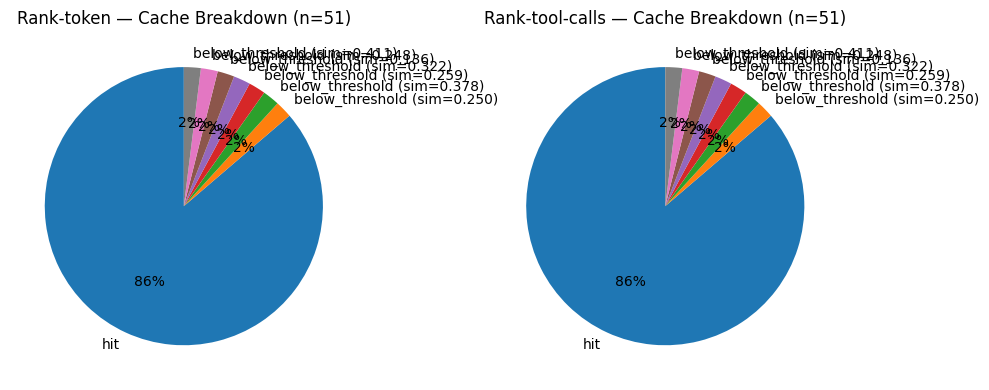

In [6]:
for sfx, label in [('tok', 'Rank-token'), ('calls', 'Rank-tool-calls')]:
    col = f'cache_reason_{sfx}'
    print(f'\n{label} cache outcome:')
    print(merged[col].value_counts().to_string())

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, sfx, label in [(axes[0], 'tok', 'Rank-token'), (axes[1], 'calls', 'Rank-tool-calls')]:
    counts = merged[f'cache_reason_{sfx}'].value_counts()
    ax.pie(counts, labels=counts.index, autopct='%1.0f%%', startangle=90)
    ax.set_title(f'{label} — Cache Breakdown (n={len(merged)})')
plt.tight_layout()
plt.show()

In [7]:
print('=== CACHE MISS CASES (rank-tool-calls run) ===')
miss_detail = miss_rows[[
    'task_id', 'rank1_sim', 'cache_reason_calls',
    'total_tokens_base', 'total_tokens_calls',
    'exact_match_base', 'exact_match_calls',
    'failure_calls'
]].copy()
miss_detail['task_id'] = miss_detail['task_id'].str[:16]
display(miss_detail.to_string(index=False))

print('\nNote: all misses have rank-1 similarity below the 0.8 threshold — '
      'the admission policy correctly withheld the template for genuinely dissimilar queries.')

=== CACHE MISS CASES (rank-tool-calls run) ===


"         task_id  rank1_sim          cache_reason_calls  total_tokens_base  total_tokens_calls  exact_match_base  exact_match_calls                        failure_calls\n4b6bb5f7-f634-41      0.250 below_threshold (sim=0.250)             270084              385181               NaN                NaN {'returncode': 1, 'stderr_tail': ''}\n99c9cc74-fdc8-46      0.378 below_threshold (sim=0.378)             234814              197009               NaN              1.000                                 None\na0068077-79f4-46      0.259 below_threshold (sim=0.259)             245434              172046               NaN              1.000                                 None\na0c07678-e491-4b      0.322 below_threshold (sim=0.322)                  0              199645               NaN              0.000                                 None\nb415aba4-4b68-4f      0.136 below_threshold (sim=0.136)             250021              398481             1.000                NaN {'returncode': 1,


Note: all misses have rank-1 similarity below the 0.8 threshold — the admission policy correctly withheld the template for genuinely dissimilar queries.


In [8]:
print('=== MISS CASE QUERIES (shared across both reuse runs) ===')
for _, row in miss_rows.iterrows():
    print(f'\n[{row["task_id"][:16]}] sim={row["rank1_sim"]:.3f}')
    print(f'  Query: {row["query_text_base"][:120]}')
    for sfx, label in [('tok', 'rank-token'), ('calls', 'rank-calls')]:
        em = row[f'exact_match_{sfx}']
        tok = row[f'total_tokens_{sfx}']
        print(f'  {label}: exact_match={em}  tokens={tok:,.0f}')

=== MISS CASE QUERIES (shared across both reuse runs) ===

[4b6bb5f7-f634-41] sim=0.250
  Query: In Series 9, Episode 11 of Doctor Who, the Doctor is trapped inside an ever-shifting maze. What is this location called 
  rank-token: exact_match=nan  tokens=382,055
  rank-calls: exact_match=nan  tokens=385,181

[99c9cc74-fdc8-46] sim=0.378
  Query: Hi, I'm making a pie but I could use some help with my shopping list. I have everything I need for the crust, but I'm no
  rank-token: exact_match=nan  tokens=401,630
  rank-calls: exact_match=1.0  tokens=197,009

[a0068077-79f4-46] sim=0.259
  Query: What was the actual enrollment count of the clinical trial on H. pylori in acne vulgaris patients from Jan-May 2018 as l
  rank-token: exact_match=1.0  tokens=171,543
  rank-calls: exact_match=1.0  tokens=172,046

[a0c07678-e491-4b] sim=0.322
  Query: Who are the pitchers with the number before and after Taishō Tamai's number as of July 2023? Give them to me in the form
  rank-token: exact_match=

---
## 3. Token Usage Analysis

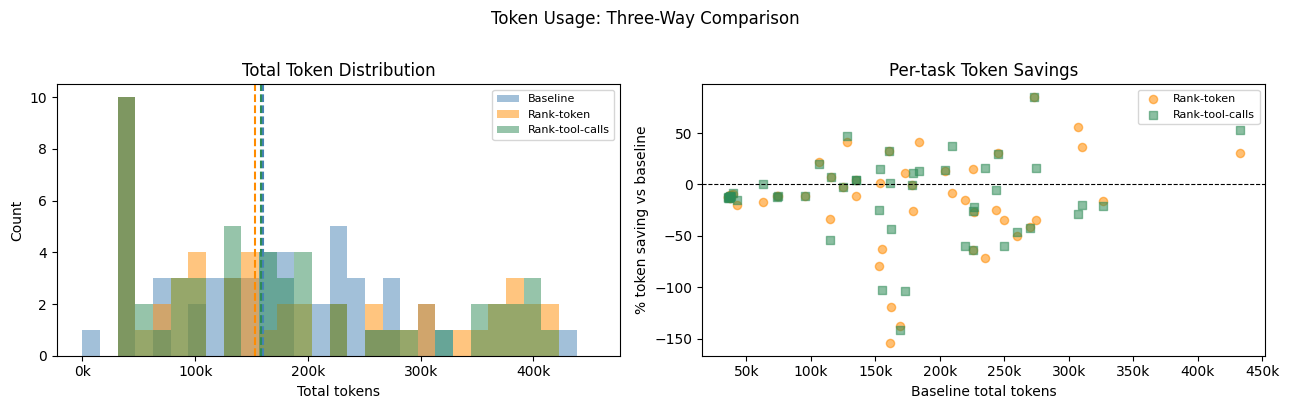

Rank-token: fewer=15/51  more=36/51  mean_save=-15.2%
Rank-tool-calls: fewer=18/51  more=33/51  mean_save=-12.2%


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# ---- Left: total token distributions ----
ax = axes[0]
max_val = max(merged['total_tokens_base'].max(),
              merged['total_tokens_tok'].max(),
              merged['total_tokens_calls'].max())
bins = np.linspace(0, max_val * 1.05, 30)
for col, color, label in [
    ('total_tokens_base',  C_BASE,  'Baseline'),
    ('total_tokens_tok',   C_TOK,   'Rank-token'),
    ('total_tokens_calls', C_CALLS, 'Rank-tool-calls'),
]:
    ax.hist(merged[col], bins=bins, alpha=0.5, label=label, color=color)
    ax.axvline(merged[col].median(), color=color, linestyle='--', lw=1.5)
ax.set_xlabel('Total tokens')
ax.set_ylabel('Count')
ax.set_title('Total Token Distribution')
ax.legend(fontsize=8)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}k'))

# ---- Right: per-task % savings scatter (both reuse variants) ----
ax = axes[1]
x = merged['total_tokens_base']
ax.scatter(x, merged['pct_token_save_tok'],
           c=C_TOK, alpha=0.55, s=35, label='Rank-token', marker='o')
ax.scatter(x, merged['pct_token_save_calls'],
           c=C_CALLS, alpha=0.55, s=35, label='Rank-tool-calls', marker='s')
ax.axhline(0, color='black', lw=0.8, linestyle='--')
ax.set_xlabel('Baseline total tokens')
ax.set_ylabel('% token saving vs baseline')
ax.set_title('Per-task Token Savings')
ax.legend(fontsize=8)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}k'))

plt.suptitle('Token Usage: Three-Way Comparison', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

for sfx, label in [('tok', 'Rank-token'), ('calls', 'Rank-tool-calls')]:
    n_less = (merged[f'delta_tokens_{sfx}'] < 0).sum()
    n_more = (merged[f'delta_tokens_{sfx}'] > 0).sum()
    mean_s = merged[f'pct_token_save_{sfx}'].mean()
    print(f'{label}: fewer={n_less}/{len(merged)}  more={n_more}/{len(merged)}  mean_save={mean_s:.1f}%')

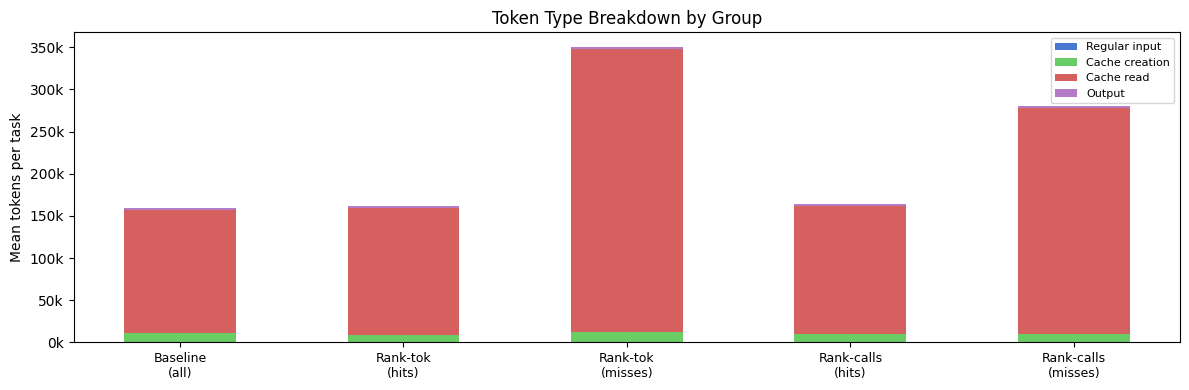

In [10]:
# Stacked bar: token type breakdown — one bar per (run × hit/miss group)
components = ['tok_input', 'tok_cache_create', 'tok_cache_read', 'tok_output']
comp_labels = ['Regular input', 'Cache creation', 'Cache read', 'Output']
colors_stack = ['#4878cf', '#6acc65', '#d65f5f', '#b47cc7']

groups = [
    ('Baseline\n(all)',         merged,                               '_base'),
    ('Rank-tok\n(hits)',        merged[merged['cache_hit_tok']==True],  '_tok'),
    ('Rank-tok\n(misses)',      merged[merged['cache_hit_tok']==False],  '_tok'),
    ('Rank-calls\n(hits)',      merged[merged['cache_hit_calls']==True], '_calls'),
    ('Rank-calls\n(misses)',    merged[merged['cache_hit_calls']==False],'_calls'),
]

bar_labels = [g[0] for g in groups]
bar_data   = np.array([
    [df[f'{c}{sfx}'].mean() for c in components]
    for _, df, sfx in groups
])

fig, ax = plt.subplots(figsize=(12, 4))
x = np.arange(len(bar_labels))
bottom = np.zeros(len(bar_labels))
for i, (comp, color) in enumerate(zip(comp_labels, colors_stack)):
    ax.bar(x, bar_data[:, i], bottom=bottom, label=comp, color=color, width=0.5)
    bottom += bar_data[:, i]
ax.set_xticks(x)
ax.set_xticklabels(bar_labels, fontsize=9)
ax.set_ylabel('Mean tokens per task')
ax.set_title('Token Type Breakdown by Group')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}k'))
ax.legend(loc='upper right', fontsize=8)
plt.tight_layout()
plt.show()

---
## 4. Latency Analysis

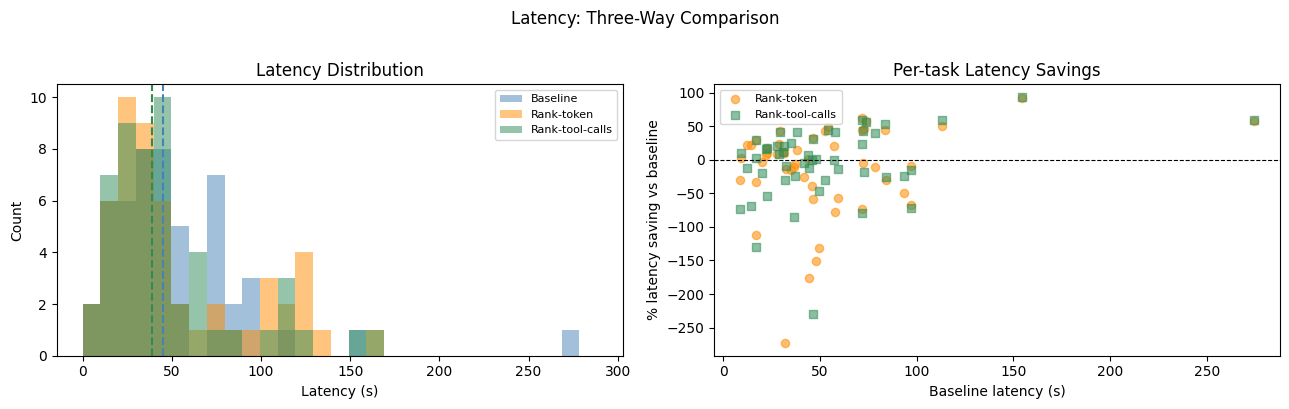

Rank-token: faster=26/51  mean_save=-12.8%
Rank-tool-calls: faster=27/51  mean_save=-4.4%


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
max_lat = max(merged['total_latency_ms_base'].max(),
              merged['total_latency_ms_tok'].max(),
              merged['total_latency_ms_calls'].max())
bins = np.linspace(0, max_lat * 1.05, 30) / 1000
for col, color, label in [
    ('total_latency_ms_base',  C_BASE,  'Baseline'),
    ('total_latency_ms_tok',   C_TOK,   'Rank-token'),
    ('total_latency_ms_calls', C_CALLS, 'Rank-tool-calls'),
]:
    ax.hist(merged[col] / 1000, bins=bins, alpha=0.5, label=label, color=color)
    ax.axvline(merged[col].median() / 1000, color=color, linestyle='--', lw=1.5)
ax.set_xlabel('Latency (s)')
ax.set_ylabel('Count')
ax.set_title('Latency Distribution')
ax.legend(fontsize=8)

ax = axes[1]
x = merged['total_latency_ms_base'] / 1000
ax.scatter(x, merged['pct_lat_save_tok'],
           c=C_TOK, alpha=0.55, s=35, label='Rank-token', marker='o')
ax.scatter(x, merged['pct_lat_save_calls'],
           c=C_CALLS, alpha=0.55, s=35, label='Rank-tool-calls', marker='s')
ax.axhline(0, color='black', lw=0.8, linestyle='--')
ax.set_xlabel('Baseline latency (s)')
ax.set_ylabel('% latency saving vs baseline')
ax.set_title('Per-task Latency Savings')
ax.legend(fontsize=8)

plt.suptitle('Latency: Three-Way Comparison', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

for sfx, label in [('tok', 'Rank-token'), ('calls', 'Rank-tool-calls')]:
    n_fast = (merged[f'delta_latency_{sfx}'] < 0).sum()
    mean_s = merged[f'pct_lat_save_{sfx}'].mean()
    print(f'{label}: faster={n_fast}/{len(merged)}  mean_save={mean_s:.1f}%')

---
## 5. Accuracy Analysis

Rank-token: improved=6  degraded=4
Rank-calls: improved=9  degraded=6

Rank-token accuracy pairs:
 acc_pair_tok
(✓Base, ✓tok)    32
(✗Base, ✗tok)     9
(✗Base, ✓tok)     6
(✓Base, ✗tok)     4

Rank-tool-calls accuracy pairs:
 acc_pair_calls
(✓Base, ✓calls)    30
(✗Base, ✓calls)     9
(✗Base, ✗calls)     6
(✓Base, ✗calls)     6


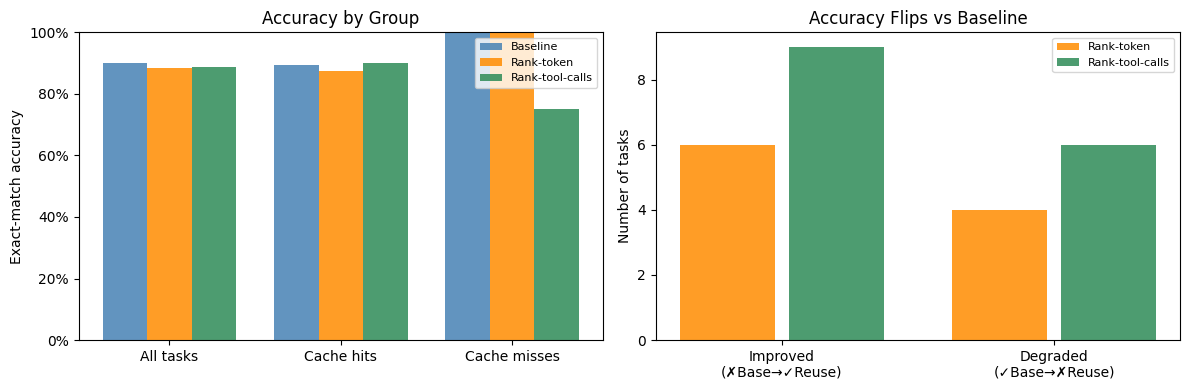

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
cats    = ['All tasks', 'Cache hits', 'Cache misses']
x       = np.arange(len(cats))
w       = 0.26
offsets = [-w, 0, w]

groups_acc = [
    ('base',  C_BASE,  'Baseline',        [merged,
                                           merged[merged['cache_hit_tok']==True],
                                           merged[merged['cache_hit_tok']==False]]),
    ('tok',   C_TOK,   'Rank-token',      [merged,
                                           merged[merged['cache_hit_tok']==True],
                                           merged[merged['cache_hit_tok']==False]]),
    ('calls', C_CALLS, 'Rank-tool-calls', [merged,
                                           merged[merged['cache_hit_calls']==True],
                                           merged[merged['cache_hit_calls']==False]]),
]
for (sfx, color, label, subsets), offset in zip(groups_acc, offsets):
    accs = [df[f'exact_match_{sfx}'].mean() for df in subsets]
    ax.bar(x + offset, accs, width=w, label=label, color=color, alpha=0.85)

ax.set_xticks(x); ax.set_xticklabels(cats)
ax.set_ylabel('Exact-match accuracy')
ax.set_ylim(0, 1)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1))
ax.set_title('Accuracy by Group')
ax.legend(fontsize=8)

# Confusion: baseline vs each reuse run
ax = axes[1]
def acc_pair_col(row, sfx):
    return ('✓Base' if row['exact_match_base']==1.0 else '✗Base',
            f'✓{sfx}'  if row[f'exact_match_{sfx}']==1.0  else f'✗{sfx}')

for sfx, color, label in [('tok', C_TOK, 'Rank-token'), ('calls', C_CALLS, 'Rank-calls')]:
    merged[f'acc_pair_{sfx}'] = merged.apply(lambda r: acc_pair_col(r, sfx), axis=1)
    fp = merged[merged[f'acc_pair_{sfx}'].apply(lambda p: p[0]=='✗Base' and p[1]==f'✓{sfx}')]
    fn = merged[merged[f'acc_pair_{sfx}'].apply(lambda p: p[0]=='✓Base' and p[1]==f'✗{sfx}')]
    print(f'{label}: improved={len(fp)}  degraded={len(fn)}')

pairs_tok   = merged['acc_pair_tok'].value_counts()
pairs_calls = merged['acc_pair_calls'].value_counts()
print('\nRank-token accuracy pairs:\n', pairs_tok.to_string())
print('\nRank-tool-calls accuracy pairs:\n', pairs_calls.to_string())

labels_flip = ['Improved\n(✗Base→✓Reuse)', 'Degraded\n(✓Base→✗Reuse)']
tok_flips   = [
    merged['acc_pair_tok'].apply(lambda p: p[0]=='✗Base' and p[1]=='✓tok').sum(),
    merged['acc_pair_tok'].apply(lambda p: p[0]=='✓Base' and p[1]=='✗tok').sum(),
]
calls_flips = [
    merged['acc_pair_calls'].apply(lambda p: p[0]=='✗Base' and p[1]=='✓calls').sum(),
    merged['acc_pair_calls'].apply(lambda p: p[0]=='✓Base' and p[1]=='✗calls').sum(),
]
x2 = np.arange(2)
ax.bar(x2 - 0.2, tok_flips,   width=0.35, label='Rank-token',      color=C_TOK,   alpha=0.85)
ax.bar(x2 + 0.2, calls_flips, width=0.35, label='Rank-tool-calls', color=C_CALLS, alpha=0.85)
ax.set_xticks(x2); ax.set_xticklabels(labels_flip)
ax.set_ylabel('Number of tasks')
ax.set_title('Accuracy Flips vs Baseline')
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

In [13]:
print('=== Tasks where accuracy CHANGED (either run) ===')
for sfx, label in [('tok', 'Rank-token'), ('calls', 'Rank-tool-calls')]:
    flipped = merged[merged['exact_match_base'] != merged[f'exact_match_{sfx}']].copy()
    flipped['direction'] = flipped.apply(
        lambda r: 'IMPROVED' if r['exact_match_base']!=1.0 and r[f'exact_match_{sfx}']==1.0 else 'DEGRADED',
        axis=1)
    print(f'\n--- {label} ({len(flipped)} flips) ---')
    cols = ['task_id', 'direction', f'exact_match_{sfx}', 'exact_match_base',
            f'final_answer_pred_{sfx}', 'final_answer_pred_base', 'ground_truth_answer_base',
            f'pct_token_save_{sfx}', f'cache_source_similarity_{sfx}']
    disp = flipped[cols].copy()
    disp['task_id'] = disp['task_id'].str[:16]
    display(disp.to_string(index=False))

=== Tasks where accuracy CHANGED (either run) ===

--- Rank-token (16 flips) ---


'         task_id direction  exact_match_tok  exact_match_base final_answer_pred_tok final_answer_pred_base                                                                            ground_truth_answer_base  pct_token_save_tok  cache_source_similarity_tok\n4b6bb5f7-f634-41  DEGRADED              NaN               NaN                   NaN                    NaN                                                                                          THE CASTLE             -41.458                          NaN\n5cfb274c-0207-4a  DEGRADED              NaN             1.000                   NaN                     No                                                                                                  No             -34.800                        0.885\n5d0080cb-90d7-47  IMPROVED            1.000               NaN                0.1777                    NaN                                                                                              0.1777             -24.734  


--- Rank-tool-calls (20 flips) ---


'         task_id direction  exact_match_calls  exact_match_base                                                                             final_answer_pred_calls final_answer_pred_base                                                                            ground_truth_answer_base  pct_token_save_calls  cache_source_similarity_calls\n0383a3ee-47a7-41  IMPROVED              1.000             0.000                                                                                  Rockhopper penguin                Penguin                                                                                  Rockhopper penguin                14.161                          0.984\n4b650a35-8529-46  IMPROVED              1.000             0.000                                                                                               Guava              Pineapple                                                                                               Guava               -12.948         

---
## 6. Step Count Analysis

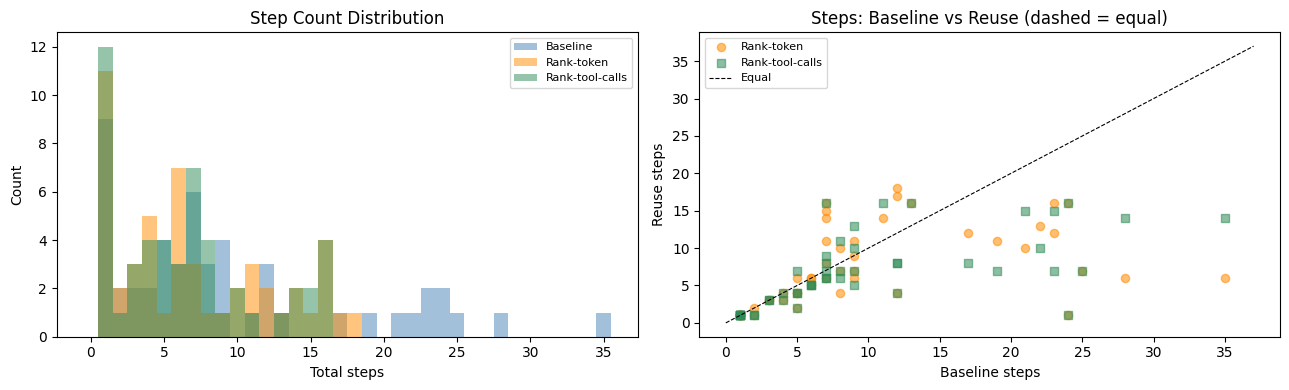

Rank-token: mean_delta=-2.49  fewer=23/51  more=12/51
Rank-tool-calls: mean_delta=-3.04  fewer=29/51  more=9/51


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
max_steps = max(merged['total_steps_base'].max(),
                merged['total_steps_tok'].max(),
                merged['total_steps_calls'].max())
bins = np.arange(0, max_steps + 2) - 0.5
for col, color, label in [
    ('total_steps_base',  C_BASE,  'Baseline'),
    ('total_steps_tok',   C_TOK,   'Rank-token'),
    ('total_steps_calls', C_CALLS, 'Rank-tool-calls'),
]:
    ax.hist(merged[col], bins=bins, alpha=0.5, label=label, color=color)
ax.set_xlabel('Total steps')
ax.set_ylabel('Count')
ax.set_title('Step Count Distribution')
ax.legend(fontsize=8)

ax = axes[1]
lim = max_steps + 2
ax.scatter(merged['total_steps_base'], merged['total_steps_tok'],
           c=C_TOK, alpha=0.55, s=35, label='Rank-token', marker='o')
ax.scatter(merged['total_steps_base'], merged['total_steps_calls'],
           c=C_CALLS, alpha=0.55, s=35, label='Rank-tool-calls', marker='s')
ax.plot([0, lim], [0, lim], 'k--', lw=0.8, label='Equal')
ax.set_xlabel('Baseline steps')
ax.set_ylabel('Reuse steps')
ax.set_title('Steps: Baseline vs Reuse (dashed = equal)')
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

for sfx, label in [('tok', 'Rank-token'), ('calls', 'Rank-tool-calls')]:
    d = merged[f'delta_steps_{sfx}']
    print(f'{label}: mean_delta={d.mean():+.2f}  fewer={( d<0).sum()}/{len(merged)}  more={(d>0).sum()}/{len(merged)}')

---
## 7. When is Plan Reuse Most Useful?

Examine how retrieval similarity correlates with token savings, latency savings, and accuracy.

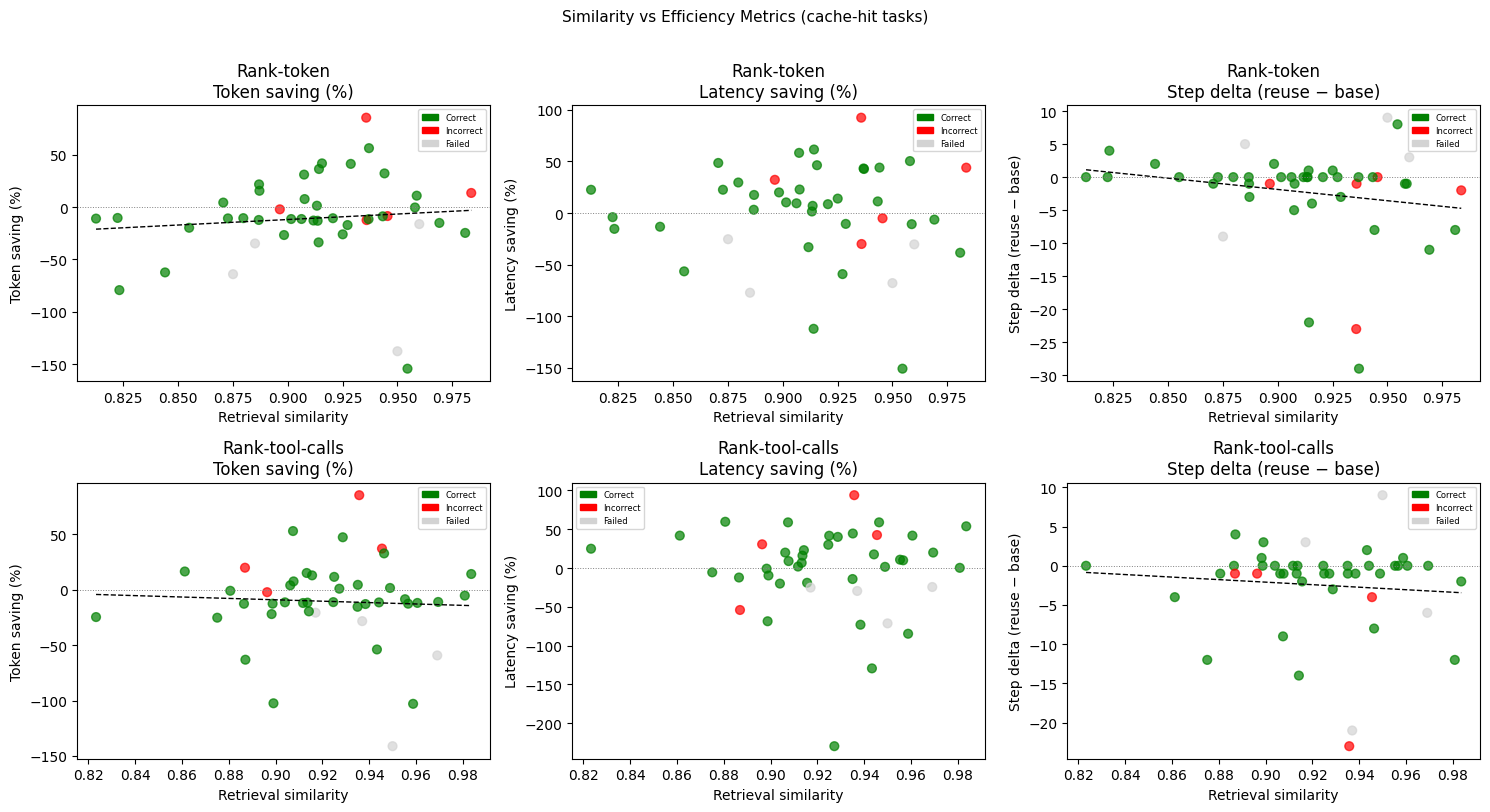

  Rank-token  corr(sim, pct_token_save_tok): +0.101
  Rank-token  corr(sim, pct_lat_save_tok): -0.038
  Rank-token  corr(sim, delta_steps_tok): -0.193
  Rank-tool-calls  corr(sim, pct_token_save_calls): -0.052
  Rank-tool-calls  corr(sim, pct_lat_save_calls): -0.064
  Rank-tool-calls  corr(sim, delta_steps_calls): -0.088


In [15]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for row_i, (sfx, label) in enumerate([('tok', 'Rank-token'), ('calls', 'Rank-tool-calls')]):
    hits_df = merged[merged[f'cache_hit_{sfx}'] == True].copy()
    sim     = hits_df[f'cache_source_similarity_{sfx}'].astype(float)

    for col_i, (y_col, y_label) in enumerate([
        (f'pct_token_save_{sfx}',  'Token saving (%)'),
        (f'pct_lat_save_{sfx}',    'Latency saving (%)'),
        (f'delta_steps_{sfx}',     'Step delta (reuse − base)'),
    ]):
        ax = axes[row_i][col_i]
        pt_colors = acc_colors(hits_df[f'exact_match_{sfx}'])
        ax.scatter(sim, hits_df[y_col].astype(float), c=pt_colors, alpha=0.7, s=40)
        z  = np.polyfit(sim, hits_df[y_col].astype(float), 1)
        xp = np.linspace(float(sim.min()), float(sim.max()), 50)
        ax.plot(xp, np.poly1d(z)(xp), 'k--', lw=1)
        ax.axhline(0, color='gray', lw=0.7, linestyle=':')
        ax.set_xlabel('Retrieval similarity')
        ax.set_ylabel(y_label)
        ax.set_title(f'{label}\n{y_label}')
        from matplotlib.patches import Patch
        ax.legend(handles=[
            Patch(color='green',     label='Correct'),
            Patch(color='red',       label='Incorrect'),
            Patch(color='lightgray', label='Failed'),
        ], fontsize=6)

plt.suptitle('Similarity vs Efficiency Metrics (cache-hit tasks)', fontsize=11, y=1.01)
plt.tight_layout()
plt.show()

for sfx, label in [('tok', 'Rank-token'), ('calls', 'Rank-tool-calls')]:
    hits_df = merged[merged[f'cache_hit_{sfx}'] == True].copy()
    sim     = hits_df[f'cache_source_similarity_{sfx}'].astype(float)
    for col in [f'pct_token_save_{sfx}', f'pct_lat_save_{sfx}', f'delta_steps_{sfx}']:
        corr = sim.corr(hits_df[col].astype(float))
        print(f'  {label}  corr(sim, {col}): {corr:+.3f}')

In [16]:
for sfx, label in [('tok', 'Rank-token'), ('calls', 'Rank-tool-calls')]:
    hits_df = merged[merged[f'cache_hit_{sfx}'] == True]
    print(f'\n=== {label} — Top 5 token savers ===')
    for _, r in hits_df.nlargest(5, f'pct_token_save_{sfx}').iterrows():
        print(f'  [{r["task_id"][:16]}] sim={r[f"cache_source_similarity_{sfx}"]:.3f}  '
              f'{r["total_tokens_base"]:,}→{r[f"total_tokens_{sfx}"]:,}  '
              f'({r[f"pct_token_save_{sfx}"]:+.1f}%)  '
              f'steps {r["total_steps_base"]}→{r[f"total_steps_{sfx}"]}  '
              f'em_base={r["exact_match_base"]}→em_reuse={r[f"exact_match_{sfx}"]}')

    print(f'\n=== {label} — Bottom 5 (reuse MORE expensive) ===')
    for _, r in hits_df.nsmallest(5, f'pct_token_save_{sfx}').iterrows():
        print(f'  [{r["task_id"][:16]}] sim={r[f"cache_source_similarity_{sfx}"]:.3f}  '
              f'{r["total_tokens_base"]:,}→{r[f"total_tokens_{sfx}"]:,}  '
              f'({r[f"pct_token_save_{sfx}"]:+.1f}%)  '
              f'steps {r["total_steps_base"]}→{r[f"total_steps_{sfx}"]}  '
              f'em_base={r["exact_match_base"]}→em_reuse={r[f"exact_match_{sfx}"]}')


=== Rank-token — Top 5 token savers ===
  [7d4a7d1d-cac6-44] sim=0.936  272,921→40,188  (+85.3%)  steps 24→1  em_base=nan→em_reuse=0.0
  [65afbc8a-89ca-4a] sim=0.937  307,119→134,572  (+56.2%)  steps 35→6  em_base=nan→em_reuse=1.0
  [5a0c1adf-205e-48] sim=0.916  183,720→107,168  (+41.7%)  steps 8→4  em_base=1.0→em_reuse=1.0
  [c365c1c7-a3db-4d] sim=0.929  128,159→75,390  (+41.2%)  steps 5→2  em_base=0.0→em_reuse=1.0
  [7bd855d8-463d-4e] sim=0.914  310,025→197,578  (+36.3%)  steps 28→6  em_base=nan→em_reuse=1.0

=== Rank-token — Bottom 5 (reuse MORE expensive) ===
  [840bfca7-4f7b-48] sim=0.955  161,239→410,086  (-154.3%)  steps 7→15  em_base=1.0→em_reuse=1.0
  [7673d772-ef80-4f] sim=0.950  169,440→402,753  (-137.7%)  steps 7→16  em_base=1.0→em_reuse=nan
  [f918266a-b3e0-49] sim=0.823  153,043→274,457  (-79.3%)  steps 7→11  em_base=1.0→em_reuse=1.0
  [9318445f-fe6a-4e] sim=0.875  225,866→370,653  (-64.1%)  steps 22→13  em_base=nan→em_reuse=nan
  [389793a7-ca17-4e] sim=0.844  155,184→25

---
## 8. Did the Agent Actually Follow the Cached Tool Sequence?

For cache-hit tasks, compare the *injected* cached tool sequence with what the agent actually executed.

Rank-token: mean_seq_sim=0.871  exact_follow=52.3%  close(>0.8)=70.5%
  Cached plan mean len=5.8  Actual mean len=5.4
Rank-tool-calls: mean_seq_sim=0.908  exact_follow=54.5%  close(>0.8)=81.8%
  Cached plan mean len=5.0  Actual mean len=5.3


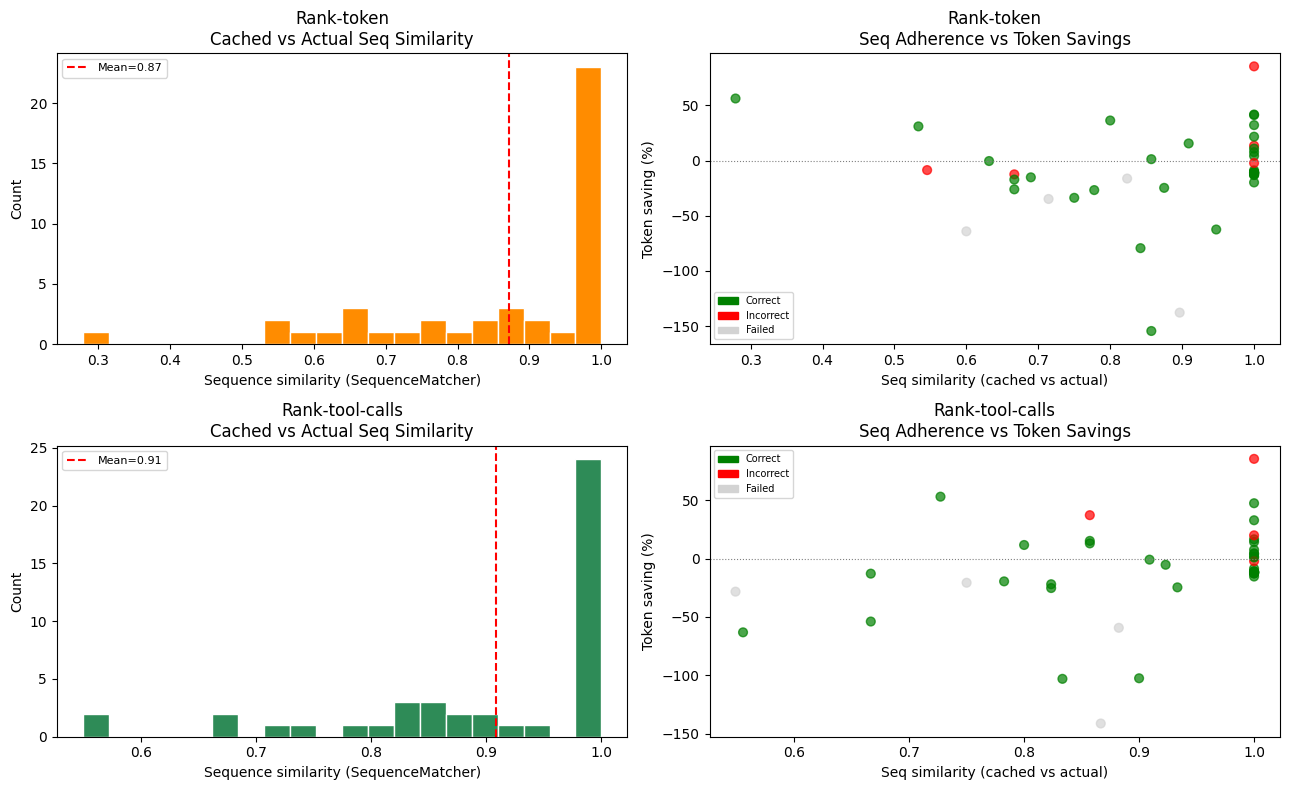

In [17]:
def seq_similarity(a, b):
    if not a or not b: return float('nan')
    return SequenceMatcher(None, a, b).ratio()

def strip_toolsearch(seq):
    return [t for t in seq if t != 'ToolSearch']

fig, axes = plt.subplots(2, 2, figsize=(13, 8))

for row_i, (sfx, label) in enumerate([('tok', 'Rank-token'), ('calls', 'Rank-tool-calls')]):
    hits_df = merged[merged[f'cache_hit_{sfx}'] == True].copy()
    hits_df['cached_clean'] = hits_df[f'cached_tool_sequence_{sfx}'].apply(
        lambda s: strip_toolsearch(s) if isinstance(s, list) else [])
    hits_df['actual_clean'] = hits_df[f'tool_sequence_{sfx}'].apply(
        lambda s: strip_toolsearch(s) if isinstance(s, list) else [])
    hits_df['seq_sim'] = hits_df.apply(
        lambda r: seq_similarity(r['cached_clean'], r['actual_clean']), axis=1)
    hits_df['cached_len'] = hits_df['cached_clean'].apply(len)
    hits_df['actual_len'] = hits_df['actual_clean'].apply(len)

    # Histogram of sequence similarity
    ax = axes[row_i][0]
    ax.hist(hits_df['seq_sim'].dropna(), bins=20, color=C_TOK if sfx=='tok' else C_CALLS, edgecolor='white')
    ax.axvline(hits_df['seq_sim'].mean(), color='red', linestyle='--',
               label=f'Mean={hits_df["seq_sim"].mean():.2f}')
    ax.set_xlabel('Sequence similarity (SequenceMatcher)')
    ax.set_ylabel('Count')
    ax.set_title(f'{label}\nCached vs Actual Seq Similarity')
    ax.legend(fontsize=8)

    # Seq similarity vs token savings
    ax = axes[row_i][1]
    pt_colors = acc_colors(hits_df[f'exact_match_{sfx}'])
    ax.scatter(hits_df['seq_sim'], hits_df[f'pct_token_save_{sfx}'].astype(float),
               c=pt_colors, alpha=0.7, s=40)
    ax.axhline(0, color='gray', linestyle=':', lw=0.8)
    ax.set_xlabel('Seq similarity (cached vs actual)')
    ax.set_ylabel('Token saving (%)')
    ax.set_title(f'{label}\nSeq Adherence vs Token Savings')
    from matplotlib.patches import Patch
    ax.legend(handles=[Patch(color='green', label='Correct'), Patch(color='red', label='Incorrect'),
                       Patch(color='lightgray', label='Failed')], fontsize=7)

    mean_sim = hits_df['seq_sim'].mean()
    exact = (hits_df['seq_sim'] == 1.0).mean()
    close = (hits_df['seq_sim'] > 0.8).mean()
    print(f'{label}: mean_seq_sim={mean_sim:.3f}  exact_follow={exact:.1%}  close(>0.8)={close:.1%}')
    print(f'  Cached plan mean len={hits_df["cached_len"].mean():.1f}  '
          f'Actual mean len={hits_df["actual_len"].mean():.1f}')

plt.tight_layout()
plt.show()

In [18]:
for sfx, label in [('tok', 'Rank-token'), ('calls', 'Rank-tool-calls')]:
    hits_df = merged[merged[f'cache_hit_{sfx}'] == True].copy()
    hits_df['cached_clean'] = hits_df[f'cached_tool_sequence_{sfx}'].apply(
        lambda s: strip_toolsearch(s) if isinstance(s, list) else [])
    hits_df['actual_clean'] = hits_df[f'tool_sequence_{sfx}'].apply(
        lambda s: strip_toolsearch(s) if isinstance(s, list) else [])
    hits_df['seq_sim'] = hits_df.apply(
        lambda r: seq_similarity(r['cached_clean'], r['actual_clean']), axis=1)

    print(f'\n=== {label} — 3 most deviated from plan ===')
    for _, r in hits_df.nsmallest(3, 'seq_sim').iterrows():
        print(f'  [{r["task_id"][:16]}] seq_sim={r["seq_sim"]:.3f}  '
              f'retrieval_sim={r[f"cache_source_similarity_{sfx}"]:.3f}  '
              f'tok_save={r[f"pct_token_save_{sfx}"]:+.1f}%')
        print(f'    Cached: {r["cached_clean"]}')
        print(f'    Actual: {r["actual_clean"]}')


=== Rank-token — 3 most deviated from plan ===
  [65afbc8a-89ca-4a] seq_sim=0.279  retrieval_sim=0.937  tok_save=+56.2%
    Cached: ['Bash', 'Bash', 'Bash', 'Bash', 'Bash', 'Bash', 'Bash', 'Bash', 'Bash', 'Bash', 'Bash', 'Bash', 'Bash', 'Bash', 'Glob', 'Glob', 'Bash', 'Bash', 'Bash', 'Bash', 'Bash', 'Bash', 'Bash', 'Bash', 'Bash', 'Glob', 'Glob', 'Bash', 'Bash', 'Bash', 'Bash', 'Bash', 'Bash', 'Bash', 'Bash', 'Bash', 'StructuredOutput']
    Actual: ['Bash', 'Bash', 'Bash', 'Bash', 'Bash', 'StructuredOutput']
  [935e2cff-ae78-42] seq_sim=0.533  retrieval_sim=0.907  tok_save=+30.9%
    Cached: ['WebFetch', 'WebFetch', 'WebFetch', 'StructuredOutput']
    Actual: ['WebFetch', 'WebFetch', 'WebFetch', 'WebFetch', 'WebFetch', 'WebFetch', 'WebFetch', 'WebFetch', 'WebFetch', 'WebFetch', 'StructuredOutput']
  [46719c30-f4c3-4c] seq_sim=0.545  retrieval_sim=0.946  tok_save=-8.6%
    Cached: ['WebSearch', 'WebFetch', 'StructuredOutput']
    Actual: ['WebSearch', 'WebFetch', 'WebFetch', 'WebFetch'

---
## 9. Cache Miss Deep Dive

For the two distinct miss reasons — *no embedding* (task not in plan-caching KB) and *below threshold* (similarity < 0.8) — inspect whether the agent behaved differently from baseline.

In [19]:
print('=== CACHE MISS: all three runs side-by-side ===')
for _, row in miss_rows.sort_values('rank1_sim').iterrows():
    print(f'\n[{row["task_id"][:16]}] sim={row["rank1_sim"]:.3f}')
    print(f'  Query: {str(row["query_text_base"])[:100]}')
    print(f'  Baseline:       tok={row["total_tokens_base"]:>8,}  lat={row["total_latency_ms_base"]/1000:>5.1f}s  steps={row["total_steps_base"]:>3}  em={row["exact_match_base"]}')
    print(f'  Rank-token:     tok={row["total_tokens_tok"]:>8,}  lat={row["total_latency_ms_tok"]/1000:>5.1f}s  steps={row["total_steps_tok"]:>3}  em={row["exact_match_tok"]}')
    print(f'  Rank-tool-calls:tok={row["total_tokens_calls"]:>8,}  lat={row["total_latency_ms_calls"]/1000:>5.1f}s  steps={row["total_steps_calls"]:>3}  em={row["exact_match_calls"]}')

=== CACHE MISS: all three runs side-by-side ===

[b415aba4-4b68-4f] sim=0.136
  Query: In Nature journal's Scientific Reports conference proceedings from 2012, in the article that did not
  Baseline:       tok= 250,021  lat= 71.5s  steps= 11  em=1.0
  Rank-token:     tok= 337,179  lat=124.3s  steps= 14  em=1.0
  Rank-tool-calls:tok= 398,481  lat=128.5s  steps= 16  em=nan

[d0633230-7067-47] sim=0.248
  Query: In the Scikit-Learn July 2017 changelog, what other predictor base command received a bug fix? Just 
  Baseline:       tok= 259,840  lat= 93.5s  steps= 23  em=nan
  Rank-token:     tok= 389,168  lat=139.2s  steps= 16  em=nan
  Rank-tool-calls:tok= 378,720  lat=116.0s  steps= 15  em=nan

[4b6bb5f7-f634-41] sim=0.250
  Query: In Series 9, Episode 11 of Doctor Who, the Doctor is trapped inside an ever-shifting maze. What is t
  Baseline:       tok= 270,084  lat= 97.2s  steps= 24  em=nan
  Rank-token:     tok= 382,055  lat=106.7s  steps= 16  em=nan
  Rank-tool-calls:tok= 385,181  lat=

---
## 10. Per-Task Full Comparison Table

In [20]:
table = merged[[
    'task_id',
    'cache_hit_calls',
    'cache_source_similarity_calls',
    'total_tokens_base',   'total_tokens_tok',   'total_tokens_calls',
    'pct_token_save_tok',  'pct_token_save_calls',
    'total_latency_ms_base', 'total_latency_ms_calls',
    'pct_lat_save_calls',
    'total_steps_base', 'total_steps_tok', 'total_steps_calls',
    'exact_match_base', 'exact_match_tok', 'exact_match_calls',
]].copy()
table['task_id'] = table['task_id'].str[:16]
table = table.rename(columns={
    'cache_hit_calls': 'hit',
    'cache_source_similarity_calls': 'sim',
    'total_tokens_base':   'tok_base',
    'total_tokens_tok':    'tok_rank_tok',
    'total_tokens_calls':  'tok_rank_calls',
    'pct_token_save_tok':  'save%_tok',
    'pct_token_save_calls':'save%_calls',
    'total_latency_ms_base':  'lat_base_ms',
    'total_latency_ms_calls': 'lat_calls_ms',
    'pct_lat_save_calls':     'latsave%',
    'total_steps_base':  's_base',
    'total_steps_tok':   's_tok',
    'total_steps_calls': 's_calls',
    'exact_match_base':  'em_base',
    'exact_match_tok':   'em_tok',
    'exact_match_calls': 'em_calls',
})
pd.set_option('display.max_rows', 60)
display(table.sort_values('save%_calls', ascending=False).to_string(index=False))

'         task_id   hit   sim  tok_base  tok_rank_tok  tok_rank_calls  save%_tok  save%_calls  lat_base_ms  lat_calls_ms  latsave%  s_base  s_tok  s_calls  em_base  em_tok  em_calls\n7d4a7d1d-cac6-44  True 0.936    272921         40188           40137     85.275       85.294   154548.000          9374    93.935      24      1        1      NaN   0.000     0.000\n935e2cff-ae78-42  True 0.907    432453        298699          203539     30.929       52.934   274653.000        112818    58.923      17     12        8      NaN   1.000     1.000\nc365c1c7-a3db-4d  True 0.929    128159         75390           67511     41.175       47.322    78260.000         46824    40.169       5      2        2    0.000   1.000     1.000\n46719c30-f4c3-4c  True 0.946    209304        227381          131655     -8.637       37.099    72008.000         41347    42.580       9      9        5    0.000   0.000     0.000\n8e867cd7-cff9-4e  True 0.946    160390        108927          107865     32.086       32.

---
## 11. Summary & Key Findings

### Setup

- **Benchmark:** GAIA Level-1, 51 test tasks
- **Agent:** Claude Code (claude-sonnet-4-6, effort=medium, max-turns=16)
- **Knowledge base:** 149 KB tasks — three paraphrases of ~50 GAIA tasks
- **Retrieval:** cosine similarity on all-MiniLM-L6-v2 embeddings; top-1 neighbor used if similarity ≥ 0.8
- **Primary strategy:** rank eligible neighbors by `total_tool_calls` (lower = better), inject as a fixed tool-sequence template

---

### Aggregate results (51 tasks)

| Metric | Baseline | Rank-token | **Rank-tool-calls** ⭐ |
|--------|----------|------------|----------------------|
| Cache hit rate | — | 86.3% (44/51) | **86.3% (44/51)** |
| Exact-match accuracy | 70.6% (36/51) | 74.5% (38/51) | **76.5% (39/51)** |
| Success rate | 78.4% (40/51) | 84.3% (43/51) | **86.3% (44/51)** |
| Mean total tokens | 159,015 | 187,104 (+15.2%) | 179,890 (+12.2%) |
| Median total tokens | 160,390 | 153,419 | 158,702 |
| Mean latency | 53.9 s | 53.7 s | **49.2 s** |
| Median latency | 44.9 s | 38.9 s | **38.7 s** |
| Mean steps | 9.6 | 7.1 (−2.5) | **6.5 (−3.0)** |

---

### Cache-hit vs cache-miss breakdown (Rank-tool-calls)

| Group | n | Exact-match (base → reuse) | Mean tokens (base → reuse) | Mean latency (base → reuse) | Mean steps (base → reuse) |
|-------|---|---------------------------|---------------------------|----------------------------|--------------------------|
| Cache hits | 44 | 89.5% → **90.0%** | 151,992 → 163,898 (+7.8%) | 51.9 s → 44.5 s (−14.3%) | 8.2 → **5.8 (−2.5)** |
| Cache misses | 7 | 100.0% → 75.0%* | 203,155 → 280,406 (+38%) | 66.0 s → 78.8 s (+19.4%) | 17.9 → 11.1 (−6.8) |

*Miss-group accuracy denominator differs: baseline answered 2/7 (both correct); reuse answered 4/7 (3 correct).  
All 7 misses had rank-1 similarity < 0.8 — the admission policy correctly withheld templates for genuinely dissimilar queries.

---

### Accuracy flip analysis (Rank-tool-calls vs Baseline)

| Outcome | Count |
|---------|-------|
| ✓ Both correct | 30 |
| ✗ Base wrong → ✓ Reuse correct (improved) | **9** |
| ✗ Both wrong | 6 |
| ✓ Base correct → ✗ Reuse wrong (degraded) | 6 |

Net: **+3 tasks** answered correctly with plan reuse (9 improved − 6 degraded).

---

### Tool-sequence adherence (cache hits, n=44)

| Metric | Rank-token | **Rank-tool-calls** |
|--------|-----------|---------------------|
| Mean cached plan length | 5.8 steps | **5.0 steps** |
| Mean actual execution length | 5.4 steps | 5.3 steps |
| Mean sequence similarity | 0.871 | **0.908** |
| Exact sequence followed | 52.3% | **54.5%** |
| Near-exact follow (sim > 0.8) | 70.5% | **81.8%** |

Ranking by step count produces shorter, tighter plans that the agent follows more faithfully.

---

### Correlation: retrieval similarity vs. outcome metrics (cache hits)

| Metric | Rank-tool-calls corr(sim, ·) |
|--------|------------------------------|
| Token saving (%) | −0.052 |
| Latency saving (%) | −0.064 |
| Step delta | −0.088 |

Retrieval similarity has **no meaningful correlation** with per-task savings or accuracy once above the 0.8 admission threshold. This suggests the threshold is a reasonable gate, but finer similarity differences within the hit set do not predict outcome.

---

### Why rank-tool-calls outperforms rank-token

`total_tokens` is dominated by `cache_read_input_tokens`, which scales with `steps × context_size`. A KB run with many short-context steps can match the token count of one with few long-context steps. Ranking by `total_tokens` therefore sometimes selects verbose plans (e.g. 15 WebFetch calls) that force the test agent into longer trajectories than necessary.

Ranking directly by `total_tool_calls` minimises plan length, producing shorter templates that:
1. Reduce steps more aggressively (−3.0 vs −2.5 vs baseline)
2. Have higher template adherence (81.8% near-exact vs 70.5%)
3. Improve accuracy more (+5.9 pp vs +3.9 pp)

---

### Token overhead and latency trade-off

Plan reuse **increases mean token count** for both strategies (+12–15% overall). The overhead has two sources:

1. **Prompt injection cost:** the cached plan template adds ~300–500 tokens to every prompt.
2. **Plan-induced detours:** when the injected plan is a poor fit, the agent executes more tool calls than it would have freely planned, sometimes doubling token usage.

Despite higher mean token counts, **median latency drops** from 44.9 s → 38.7 s (−14%), because:
- Most tasks complete in fewer turns (steps 8.2→5.8 for hits), reducing round-trip LLM calls.
- The token overhead is largely cache-read tokens (billed at 0.1×), which do not significantly increase wall-clock time.

Effective cost is therefore lower than raw token counts suggest. A true cost analysis using billing rates (input: 1×, cache creation: 1.25×, cache read: 0.1×, output: 5×) would likely show net savings for cache-hit tasks.

---

### Caveats

1. **KB built from paraphrases of test tasks** — retrieval similarity is artificially high (mean rank-1 sim = 0.84). Production KB retrieval over unrelated tasks would produce lower similarities and more misses.
2. **Non-determinism** — web content varies across runs; some per-task delta is irreducible noise.
3. **Fixed threshold** — the 0.8 similarity threshold was set heuristically. A lower threshold (e.g. 0.7) would increase hit rate but may inject lower-quality plans.
4. **Single-model evaluation** — results are for claude-sonnet-4-6 at effort=medium; other models or effort levels may respond differently to injected plans.